In [ ]:
pip install faker

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 28.2 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


sns.set()

In [ ]:
np.random.seed(42)

n = 250

data = {
    "Student_ID": range(1, n+1),
    "Name": [f"Student_{i}" for i in range(1, n+1)],
    "Gender": np.random.choice(["Male", "Female"], n),
    "Department": np.random.choice(["CSE", "IT", "ECE"], n),
    "Year": np.random.choice(["1st", "2nd", "3rd"], n),
    "Maths": np.random.randint(35, 100, n),
    "Science": np.random.randint(35, 100, n),
    "English": np.random.randint(35, 100, n),
    "Attendance": np.random.randint(50, 101, n),
    "Internal_Marks": np.random.randint(0, 26, n)
}

df = pd.DataFrame(data)

df.head()

,Student_ID,Name,Gender,Department,Year,Maths,Science,English,Attendance,Internal_Marks
0,1,Student_1,Male,IT,1st,92,51,65,81,25
1,2,Student_2,Female,CSE,2nd,78,43,40,85,23
2,3,Student_3,Male,CSE,2nd,79,49,74,99,19
3,4,Student_4,Male,CSE,2nd,66,58,46,53,4
4,5,Student_5,Male,ECE,3rd,79,72,87,76,3


In [ ]:

df["Total"] = df["Maths"] + df["Science"] + df["English"]
df["Average"] = df["Total"] / 3

def grade(avg):
    if avg >= 90:
        return "A+"
    elif avg >= 75:
        return "A"
    elif avg >= 60:
        return "B"
    elif avg >= 50:
        return "C"
    else:
        return "Fail"

df["Grade"] = df["Average"].apply(grade)

df.head()

,Student_ID,Name,Gender,Department,Year,Maths,Science,English,Attendance,Internal_Marks,Total,Average,Grade
0,1,Student_1,Male,IT,1st,92,51,65,81,25,208,69.333333,B
1,2,Student_2,Female,CSE,2nd,78,43,40,85,23,161,53.666667,C
2,3,Student_3,Male,CSE,2nd,79,49,74,99,19,202,67.333333,B
3,4,Student_4,Male,CSE,2nd,66,58,46,53,4,170,56.666667,C
4,5,Student_5,Male,ECE,3rd,79,72,87,76,3,238,79.333333,A


In [ ]:
print(df.describe())

       Student_ID       Maths     Science     English  Attendance  \
count  250.000000  250.000000  250.000000  250.000000  250.000000   
mean   125.500000   65.976000   66.668000   68.316000   74.116000   
std     72.312977   19.745556   18.203826   18.773436   14.199049   
min      1.000000   35.000000   35.000000   35.000000   50.000000   
25%     63.250000   48.250000   51.250000   51.000000   62.000000   
50%    125.500000   65.000000   67.000000   70.000000   73.000000   
75%    187.750000   84.000000   83.000000   84.750000   85.000000   
max    250.000000   99.000000   99.000000   99.000000  100.000000   

       Internal_Marks       Total     Average  
count      250.000000  250.000000  250.000000  
mean        12.188000  200.960000   66.986667  
std          7.666273   34.092928   11.364309  
min          0.000000  122.000000   40.666667  
25%          5.000000  175.250000   58.416667  
50%         12.000000  201.000000   67.000000  
75%         19.000000  225.750000   75.250

In [ ]:

top_students = df.sort_values(by="Total", ascending=False).head(5)
print("Top Performers:\n", top_students)

fail_students = df[df["Grade"] == "Fail"]
print("\nFailed Students:\n", fail_students)

Top Performers:
      Student_ID         Name  Gender Department Year  Maths  Science  English  \
35           36   Student_36    Male        ECE  2nd     98       85       96   
149         150  Student_150  Female        CSE  3rd     90       83       96   
135         136  Student_136    Male         IT  1st     76       93       99   
188         189  Student_189    Male         IT  1st     76       99       93   
60           61   Student_61    Male        ECE  1st     83       89       96   

     Attendance  Internal_Marks  Total    Average Grade  
35           95               0    279  93.000000    A+  
149          71              22    269  89.666667     A  
135          87              19    268  89.333333     A  
188          80              24    268  89.333333     A  
60           78               1    268  89.333333     A  

Failed Students:
      Student_ID         Name  Gender Department Year  Maths  Science  English  \
20           21   Student_21  Female        CSE 

In [ ]:

dept_perf = df.groupby("Department")["Average"].mean()
print(dept_perf)

gender_perf = df.groupby("Gender")["Average"].mean()
print(gender_perf)


year_perf = df.groupby("Year")["Average"].mean()
print(year_perf)

Department
CSE    66.722222
ECE    67.304878
IT     66.940476
Name: Average, dtype: float64
Gender
Female    66.099462
Male      67.859788
Name: Average, dtype: float64
Year
1st    68.103333
2nd    65.918803
3rd    66.592593
Name: Average, dtype: float64


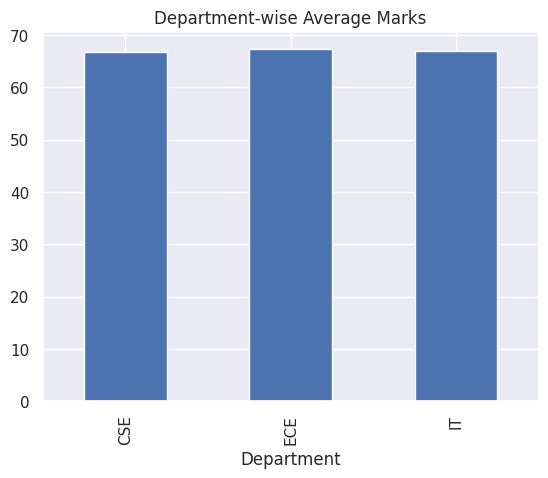

In [ ]:
dept_perf.plot(kind="bar", title="Department-wise Average Marks")
plt.show()

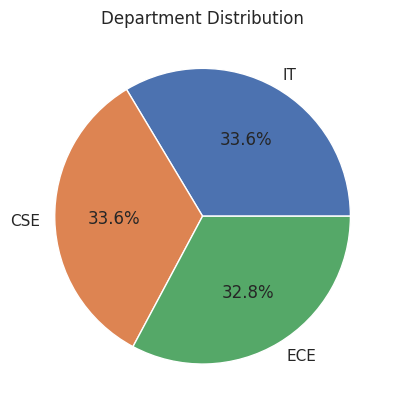

In [ ]:
df["Department"].value_counts().plot(kind="pie", autopct='%1.1f%%')
plt.title("Department Distribution")
plt.ylabel("")
plt.show()

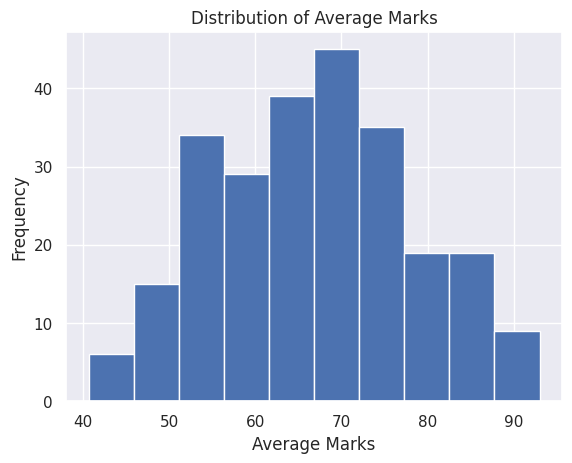

In [ ]:
plt.hist(df["Average"])
plt.title("Distribution of Average Marks")
plt.xlabel("Average Marks")
plt.ylabel("Frequency")
plt.show()

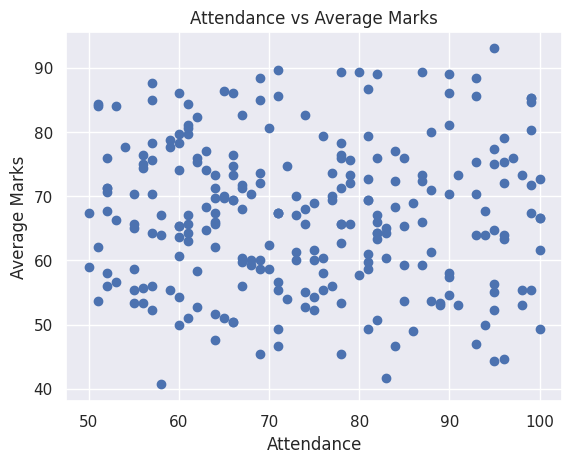

In [ ]:
plt.scatter(df["Attendance"], df["Average"])
plt.title("Attendance vs Average Marks")
plt.xlabel("Attendance")
plt.ylabel("Average Marks")
plt.show()

In [ ]:
print("Average Marks:", df["Average"].mean())
print("Highest Marks:", df["Total"].max())
print("Lowest Marks:", df["Total"].min())

Average Marks: 66.98666666666666
Highest Marks: 279
Lowest Marks: 122
